In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv


# **LOADING THE LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

# Load the Dataset

In [3]:
test_data = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv")
train_data = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv")
sample_data = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv")

In [4]:
df = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv") 

# Exploring the Data


In [5]:
df.head()

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2009-04-17,26,blue-collar,married,secondary,no,647,yes,no,cellular,357,2,331,1,other,no
1,2009-10-11,52,technician,married,secondary,no,553,yes,no,telephone,160,1,-1,0,NaN,no
2,2010-11-20,44,blue-collar,married,secondary,no,1397,no,no,cellular,326,1,-1,0,NaN,no
3,2009-09-01,33,admin.,married,secondary,no,394,yes,no,telephone,104,3,-1,0,NaN,no
4,2008-01-29,31,entrepreneur,single,tertiary,no,137,no,no,cellular,445,2,-1,0,NaN,no


In [6]:
print("The columns in the train dataset are",train_data.columns.tolist())
print("The shape of the test dataset is",train_data.shape)

The columns in the train dataset are ['last contact date', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'target']
The shape of the test dataset is (39211, 16)


****Above code result shows we have 16 features and 39211 datapoints********

**Checking for missing values:**

In [7]:
print(df.isnull().sum()) 

last contact date        0
age                      0
job                    229
marital                  0
education             1467
default                  0
balance                  0
housing                  0
loan                     0
contact              10336
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             29451
target                   0
dtype: int64


*****The columns job, education, contact and poutcome have missing values**

In [8]:
df.info()     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   last contact date  39211 non-null  object
 1   age                39211 non-null  int64 
 2   job                38982 non-null  object
 3   marital            39211 non-null  object
 4   education          37744 non-null  object
 5   default            39211 non-null  object
 6   balance            39211 non-null  int64 
 7   housing            39211 non-null  object
 8   loan               39211 non-null  object
 9   contact            28875 non-null  object
 10  duration           39211 non-null  int64 
 11  campaign           39211 non-null  int64 
 12  pdays              39211 non-null  int64 
 13  previous           39211 non-null  int64 
 14  poutcome           9760 non-null   object
 15  target             39211 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.

**Insights**
***out of 16 features, 10 are categirocal feature and 6 are numerical features*

In [9]:
print(df.describe())  

                age        balance      duration      campaign         pdays  \
count  39211.000000   39211.000000  39211.000000  39211.000000  39211.000000   
mean      42.120247    5441.781719    439.062789      5.108770     72.256051   
std       12.709352   16365.292065    769.096291      9.890153    160.942593   
min       18.000000   -8019.000000      0.000000      1.000000     -1.000000   
25%       33.000000      98.000000    109.000000      1.000000     -1.000000   
50%       40.000000     549.000000    197.000000      2.000000     -1.000000   
75%       50.000000    2030.000000    380.000000      4.000000     -1.000000   
max       95.000000  102127.000000   4918.000000     63.000000    871.000000   

           previous  
count  39211.000000  
mean      11.826171  
std       44.140259  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max      275.000000  


**Insights**

**1. The average age in dataset is 42 years and max age has gone to 95years.2. The mean and median(50%) of age column are close (mean = 42.1, median = 40), indicating a roughly symmetric distribution.3. The Mean = 5441.78 vs. Median (50%) = 549: A significant difference, with a very high standard deviation (16365), indicates outliers or a right-skewed distribution.**


In [10]:
df.describe(include=['object'])

,last contact date,job,marital,education,default,housing,loan,contact,poutcome,target
count,39211,38982,39211,37744,39211,39211,39211,28875,9760,39211
unique,1013,11,3,3,2,2,2,2,3,2
top,2009-05-15,blue-collar,married,secondary,no,yes,no,cellular,failure,no
freq,313,7776,22691,19584,36954,21657,31820,25030,4949,33384


In [11]:
print(df['target'].value_counts()) 

target
no     33384
yes     5827
Name: count, dtype: int64


**Insights:**

**There are 33,384 instances labeled as "no" in the target columnabd there are 5,827 instances labeled as "yes" in the target column. This shows data is highly imbalance**


The Dataset is Highly Imbalance

# **Visualization of data**

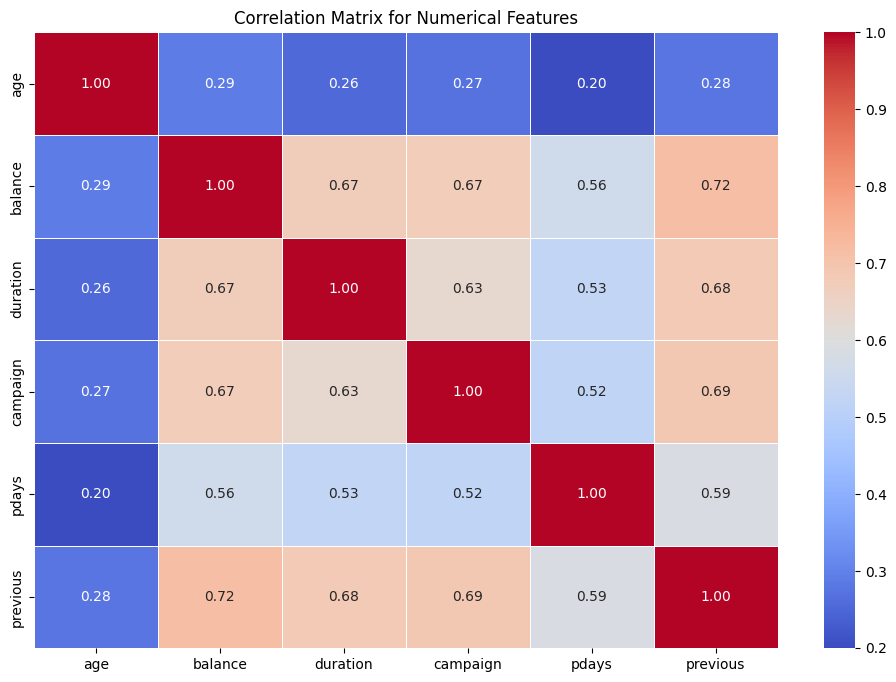

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = df.select_dtypes(include=['int64'])

correlation_matrix = numerical_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

***Insights: 'balance' and 'previous' have a strong correlation(0.72), suggesting that customers with higher balances tend to have more previous interactions and 'duration, and 'campaign' show a moderate relation of 0.63, which indicates that the longer calls are associated with more campaign contacts**

In [13]:
print(correlation_matrix)

               age   balance  duration  campaign     pdays  previous
age       1.000000  0.289150  0.255573  0.269439  0.199507  0.277487
balance   0.289150  1.000000  0.669737  0.674339  0.562097  0.716816
duration  0.255573  0.669737  1.000000  0.630944  0.527020  0.683951
campaign  0.269439  0.674339  0.630944  1.000000  0.519469  0.689211
pdays     0.199507  0.562097  0.527020  0.519469  1.000000  0.586175
previous  0.277487  0.716816  0.683951  0.689211  0.586175  1.000000


Text(0.5, 1.0, 'Boxplot of age feature')

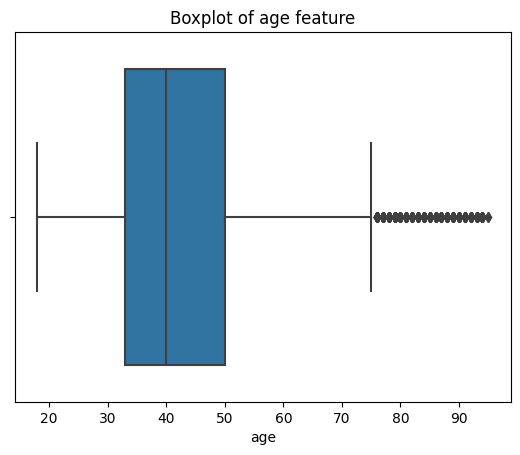

In [14]:
ax = sns.boxplot(df,x='age')
ax.set_title('Boxplot of age feature')

Text(0.5, 1.0, 'Boxplot of balance ')

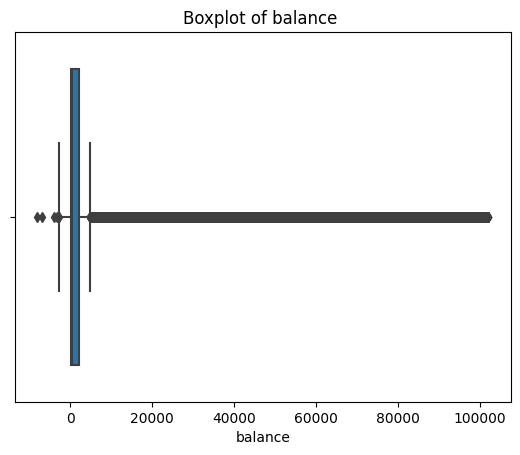

In [15]:
ax = sns.boxplot(df,x='balance')
ax.set_title('Boxplot of balance ')

**Insight: There are many outliers are present in balance feature**

Text(0.5, 1.0, 'Boxplot of duration feature')

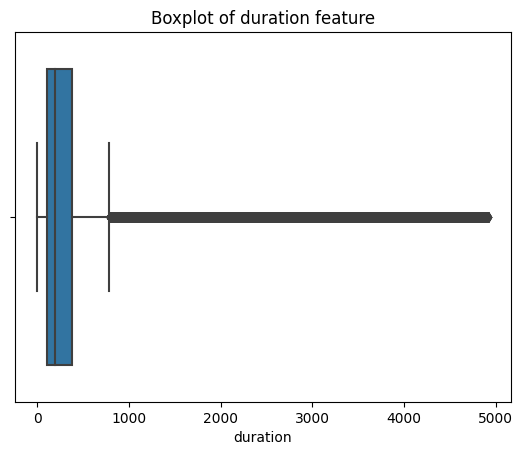

In [16]:
ax = sns.boxplot(df,x='duration')
ax.set_title('Boxplot of duration feature')

**Insight:**Call Durations: outliers are at the right end, this may indicate customers who were more engaged in the call, willing to listen, and potentially interested in the bank’s offe**r.**

Text(0.5, 1.0, 'Boxplot of campaign feature')

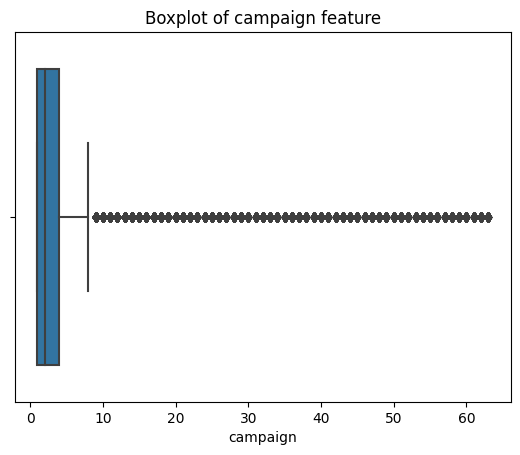

In [17]:
ax = sns.boxplot(df,x='campaign')
ax.set_title('Boxplot of campaign feature')

**High values in 'campaign' typically indicate customers who were contacted multiple times. This might mean they were difficult to reach, hesitant, or initially unresponsive.**

Text(0.5, 1.0, 'Boxplot of pdays feature')

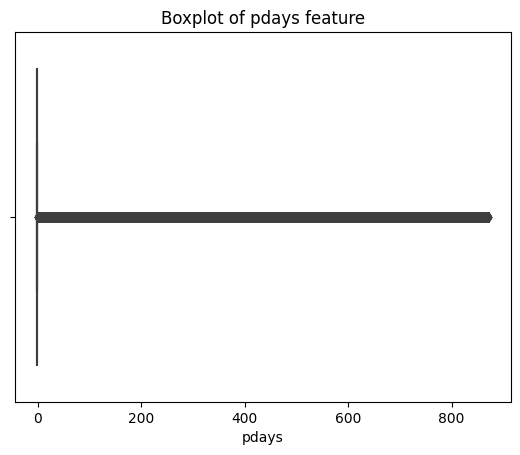

In [18]:
ax = sns.boxplot(df,x='pdays')
ax.set_title('Boxplot of pdays feature')

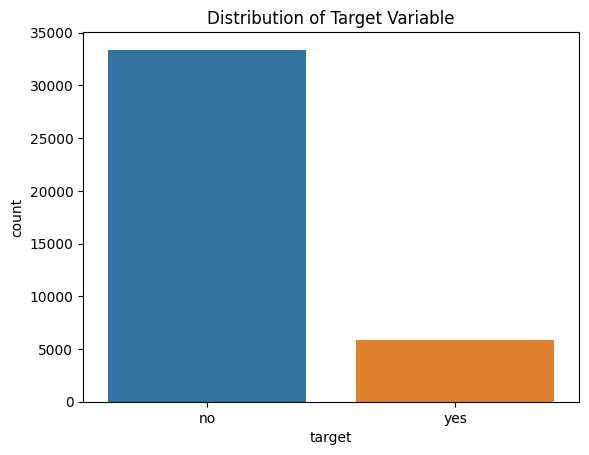

In [19]:

sns.countplot(data=df, x='target')
plt.title('Distribution of Target Variable')
plt.show()

# **DATA Preprocessing**

 **PREPROCESSING**
******

*splitting the data into Feature & Label vector*

***splitting the data into Training and Validation***

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector as mcs

In [21]:
df.rename(columns={'last contact date': 'last_contact_date'}, inplace=True)
df['last_contact_date'] = pd.to_datetime(df['last_contact_date'])
df['year'] = df['last_contact_date'].dt.year
df['month'] = df['last_contact_date'].dt.month
df['day'] = df['last_contact_date'].dt.day

df = df.drop(columns=['last_contact_date'])

Pipeline

In [22]:
type(df['day'])

pandas.core.series.Series

In [23]:
y= df.target
x= df.drop('target',axis=1)

x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.1,random_state=42)



In [24]:


cat_pipe = Pipeline([("imputer", SimpleImputer(strategy='most_frequent')),
                    ("ohe", OneHotEncoder(handle_unknown="ignore",sparse_output= False))])
num_pipe = Pipeline([("imputer", KNNImputer(n_neighbors=5)),
                     ("std", StandardScaler())])
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
num_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'year', 'month', 'day']

Trf = ColumnTransformer([('cat', cat_pipe, (cat_features)),
                        ('num', num_pipe, (num_features))])

Trf.fit(x_train)

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'poutcome']),
                                ('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('std', StandardScaler())]),
                                 ['age', 'balance', 'duration', 'campaign',
                                  'pdays', 'previous', 'year', 'month',
                                  'day'])])

In [25]:
x_train_trf = Trf.transform(x_train)
x_val_trf = Trf.transform(x_val)

In [26]:
x_train_trf.shape

(35289, 37)

In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.fit_transform(y_val)


****SMOTEENN Techinque for imbalance data****

In [28]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)
x_train_sm, y_train_sm = smoteenn.fit_resample(x_train_trf, y_train_encoded)


In [29]:
from collections import Counter
print(Counter(y_train_sm))

Counter({1: 28346, 0: 23057})


In [30]:
x_train_sm.shape, y_train_sm.shape

((51403, 37), (51403,))

# MODELING

# **Dummyclassifier**

In [31]:
from sklearn.dummy import DummyClassifier
dc =  DummyClassifier( strategy = 'most_frequent',random_state=42)

dc.fit(x_train_sm, y_train_sm)

DummyClassifier(random_state=42, strategy='most_frequent')

In [32]:
from sklearn.metrics import f1_score

print(f1_score(y_train_sm,dc.predict(x_train_sm),average='macro' ),
      (f1_score(y_val_encoded, dc.predict(x_val_trf), average='macro')))


0.35544019360744333 0.1315323294951284


In [33]:
from sklearn.metrics import classification_report as cr
print(cr(y_train_sm, dc.predict(x_train_sm)))

print('-----------')

print(cr(y_val_encoded, dc.predict(x_val_trf)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     23057
           1       0.55      1.00      0.71     28346

    accuracy                           0.55     51403
   macro avg       0.28      0.50      0.36     51403
weighted avg       0.30      0.55      0.39     51403

-----------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3328
           1       0.15      1.00      0.26       594

    accuracy                           0.15      3922
   macro avg       0.08      0.50      0.13      3922
weighted avg       0.02      0.15      0.04      3922



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

# Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=3, max_iter=1000)

lr.fit(x_train_sm, y_train_sm)

print((f1_score(y_train_sm,lr.predict(x_train_sm),average='macro' ),
      (f1_score(y_val_encoded, lr.predict(x_val_trf), average='macro')))
)

(0.8855281288998772, 0.7082927765566143)


In [35]:
from sklearn.metrics import classification_report as cr
print(cr(y_train_sm, lr.predict(x_train_sm)))

print('-----------')

print(cr(y_val_encoded, lr.predict(x_val_trf)))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88     23057
           1       0.91      0.88      0.90     28346

    accuracy                           0.89     51403
   macro avg       0.88      0.89      0.89     51403
weighted avg       0.89      0.89      0.89     51403

-----------
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      3328
           1       0.41      0.83      0.55       594

    accuracy                           0.79      3922
   macro avg       0.69      0.81      0.71      3922
weighted avg       0.88      0.79      0.82      3922



**The model struggles with the minority class1, reflected by low precision(41%), it has high recall. where class0 has high precision  but lower recall. The overall acurracy of 89% means strong performance on the training set and 79% accuracy on the validation set data is influenced majorly by moajority class.**

# XGBOOST

In [36]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators = 100, use_label_encoder = False, eval_metric = 'logloss')

xgb_model.fit(x_train_sm, y_train_sm)

print((f1_score(y_train_sm, xgb_model.predict(x_train_sm),average='macro' ),
      (f1_score(y_val_encoded, xgb_model.predict(x_val_trf), average='macro')))
)

(0.9850453047196183, 0.7602209362383919)


In [37]:
from sklearn.metrics import classification_report as cr
print(cr(y_train_sm, xgb_model.predict(x_train_sm)))

print('-----------')

print(cr(y_val_encoded, xgb_model.predict(x_val_trf)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     23057
           1       0.99      0.98      0.99     28346

    accuracy                           0.99     51403
   macro avg       0.98      0.99      0.99     51403
weighted avg       0.99      0.99      0.99     51403

-----------
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      3328
           1       0.51      0.77      0.61       594

    accuracy                           0.85      3922
   macro avg       0.73      0.82      0.76      3922
weighted avg       0.89      0.85      0.86      3922



**For training set the precision and recall are very high for both the classes, indicating minimal false positives and false negatives. For validation set data the model is performing well for the dominant class 0 but struggles with the minority class 1 . the low F1 score 61% reflectes porr overall performance for this class.**

# linearSVC

In [38]:
import time
from sklearn.svm import LinearSVC, SVC

l_svc = LinearSVC(random_state =42, class_weight ='balanced')
a = time.time()
l_svc.fit(x_train_sm, y_train_sm)
b= time.time()

print(b-a)
print((f1_score(y_train_sm,l_svc.predict(x_train_sm),average='macro' ),
      (f1_score(y_val_encoded, l_svc.predict(x_val_trf), average='macro'))))


11.657367467880249
(0.8759231169369079, 0.7108965578990714)


/opt/conda/lib/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [39]:
from sklearn.metrics import classification_report as cr
print(cr(y_train_sm, l_svc.predict(x_train_sm)))

print('-----------')

print(cr(y_val_encoded, l_svc.predict(x_val_trf)))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     23057
           1       0.93      0.84      0.88     28346

    accuracy                           0.88     51403
   macro avg       0.88      0.88      0.88     51403
weighted avg       0.88      0.88      0.88     51403

-----------
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      3328
           1       0.42      0.77      0.55       594

    accuracy                           0.81      3922
   macro avg       0.69      0.79      0.71      3922
weighted avg       0.87      0.81      0.83      3922



**The model performs well on a balanced dataset, slightly higher precision for class 1 and for validation set model low percision means large number of false positives and recall is reasonable 77% mening it identified most actuall class 1 instance**

****

# Hyper Parameter Tuning

In [40]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Tunnig of XGBOOST

In [41]:
from sklearn.model_selection import StratifiedKFold

In [42]:
xbg_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_grid= {
      'n_estimators': [50, 100, 200],
      'max_depth': [3, 4, 5],  
      'learning_rate': [0.01, 0.05, 0.1], 
      'subsample': [0.2, 0.3, 0.5 ], 
      'colsample_bytree': [0.6, 0.8, 1.0],  
      'min_child_weight': [1, 3, 5], 
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [43]:
rscv = RandomizedSearchCV(estimator = xbg_model, param_distributions = param_grid, n_iter = 10, cv =cv, scoring = 'f1_macro', n_jobs=-1, random_state=42)
rscv.fit(x_train_sm, y_train_sm)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           imp...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.2, 0.3, 0.5]},
                   random_state=42, scoring='f1_macro')

In [44]:
print(rscv.best_params_)
print(rscv.best_score_)

{'subsample': 0.3, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
0.9494475033098009


In [45]:
best_xgb = rscv.best_estimator_

train_f1 = f1_score(y_train_sm, best_xgb.predict(x_train_sm), average='macro')
test_f1 = f1_score(y_val_encoded, best_xgb.predict(x_val_trf), average='macro')

print(train_f1)
print(test_f1)

0.9517247620169595
0.7455689160489638


**Probabilities output for each class**

In [46]:
from sklearn.metrics import precision_recall_curve

y_val_pred_proba = best_xgb.predict_proba(x_val_trf)[:, 1]  
precision, recall, thresholds = precision_recall_curve(y_val_encoded, y_val_pred_proba)
f1_scores = [2 * (p * r) / (p + r) if p + r > 0 else 0 for p, r in zip(precision, recall)]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold}")

Best Threshold: 0.5736462473869324


In [47]:
y_val_pred = (y_val_pred_proba >= best_threshold).astype(int)
print(best_threshold)


0.57364625


In [48]:
test_data.columns

Index(['last contact date', 'age', 'job', 'marital', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

In [49]:
test_data.rename(columns={'last contact date': 'last_contact_date'}, inplace=True)
test_data['last_contact_date'] = pd.to_datetime(test_data['last_contact_date'])
test_data['year'] = test_data['last_contact_date'].dt.year
test_data['month'] = test_data['last_contact_date'].dt.month
test_data['day'] = test_data['last_contact_date'].dt.day

test_data = test_data.drop(columns=['last_contact_date'])

In [50]:
X_test_processed = Trf.transform(test_data)

In [51]:
test_pred_proba = best_xgb.predict_proba(X_test_processed)[:, 1]
test_pred = (test_pred_proba>=best_threshold).astype(int)

# Submission 

In [52]:
submission = pd.DataFrame({
    'id' : np.arange(len(test_pred)),
    'target' : np.where(test_pred == 1, 'yes', 'no')
})

In [53]:
submission.to_csv('Submission.csv', index=False)